# Regressão de NPS 📊

## Sobre a base de dados 🎲
O dataset utilizado representa um cenário de um **e-commerce**, que enfrenta desafios relacionados à **experiência do cliente**.  

Cada registro corresponde a um **pedido realizado**, contendo informações sobre o cliente, detalhes da compra, logística de entrega e interações com o atendimento.

A base inclui variáveis como tempo de entrega, atrasos, valor do pedido, número de contatos com suporte, reclamações e indicadores internos de satisfação.

---

## Uso da base 🛠️
O conjunto de dados pode ser utilizado para:

- Análises de **experiência do cliente (CX)**
- Identificação de **fatores que impactam o NPS**
- Construção de **modelos preditivos de satisfação**
- Geração de **insights para áreas como logística, atendimento e produto**

---

## Objetivo do projeto 🎯
Este projeto tem como objetivo **analisar os fatores que influenciam a satisfação do cliente** e **desenvolver um modelo preditivo para estimar o NPS** antes da coleta oficial.

A proposta é permitir que a empresa atue de forma **proativa**, antecipando problemas e melhorando a experiência do cliente ao longo da jornada.

---

## Contexto de negócio 💼

![Jornada do Cliente e NPS](../images/nps-image-example.png)

O NPS (Net Promoter Score) é um dos principais indicadores de satisfação e lealdade do cliente.  

Atualmente, ele é coletado apenas após a finalização da compra, o que limita a capacidade da empresa de agir preventivamente.

Com o uso de dados operacionais, buscamos responder:
- O que leva um cliente a ser promotor ou detrator?
- Quais etapas da jornada impactam mais a experiência?
- Como antecipar a satisfação do cliente?

---

## Impacto esperado 🚀
Com essa análise, espera-se:

- Melhorar a **experiência do cliente**
- Reduzir **detratores**
- Aumentar **recompra e fidelização**
- Apoiar decisões estratégicas com base em dados

---

In [ ]:
#Libs - Exploração e Manipulação de dados

import pandas as pd
import numpy as np

#Libs Gráficas
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# Paletas
NPS_COLORS   = {'Detrator': '#e74c6f', 'Neutro': '#f0a500', 'Promotor': '#2ec4b6'}
REGION_PAL   = ['#7c4dff','#00bcd4','#ff6f61','#ffd54f','#69f0ae']
DIVERGE_CMAP = 'RdYlGn'
HEAT_CMAP    = LinearSegmentedColormap.from_list('nps', ['#e74c6f','#f0a500','#2ec4b6'])



## 1. ENTENDIMENTO DOS DADOS - EDA Detalhado

Conhecer os dados é uma etapa essencial na construção de um modelo de aprendizado de máquina. 

Nessa fase, exploramos o conjunto de dados, criamos gráficos, testamos hipóteses e validamos as informações com a área de negócio para garantir qualidade e entendimento dos dados.

In [39]:
# Carregar dados
df = pd.read_csv('../data/desafio_nps_fase_1.csv')
df.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


In [40]:
# Análise de valores ausentes e tipos de dados
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                2500 non-null   int64  
 1   customer_age               2500 non-null   int64  
 2   customer_region            2500 non-null   str    
 3   customer_tenure_months     2500 non-null   int64  
 4   order_id                   2500 non-null   int64  
 5   order_value                2500 non-null   float64
 6   items_quantity             2500 non-null   int64  
 7   discount_value             2500 non-null   float64
 8   payment_installments       2500 non-null   int64  
 9   delivery_time_days         2500 non-null   int64  
 10  delivery_delay_days        2500 non-null   int64  
 11  freight_value              2500 non-null   float64
 12  delivery_attempts          2500 non-null   int64  
 13  customer_service_contacts  2500 non-null   int64  
 14  res


---
### Variável alvo: `nps_score`

Beleza, para o nosso projeto agora precisamos definir uma variável alvo.  
De todas as disponíveis na base, a que mais faz sentido para o case é o `nps_score`, pois representa diretamente a satisfação do cliente.

**Riscos**  
A nota pode ser influenciada por situações pontuais.

**Momento da coleta**  
O NPS é coletado no final da jornada, depois que a experiência já aconteceu.

---

### Faixas de avaliação de satisfação 📊

#### NPS (Net Promoter Score)

- **Promotores**: notas 9 ou 10  
- **Neutros**: notas 7 ou 8  
- **Detratores**: notas de 0 a 6  

---

#### CSAT (Customer Satisfaction Score)
O CSAT mede a **satisfação direta do cliente com uma experiência específica**, como uma compra ou atendimento.

![Exemplo de escala CSAT](../images/CSAT-EXAMPLE.jpg)

- **0 a 2**: Muito insatisfeito  
- **2 a 4**: Insatisfeito  
- **4 a 6**: Indiferente  
- **6 a 8**: Satisfeito  
- **8 a 10**: Muito satisfeito  

In [41]:
# NPS
nps = pd.cut(df['nps_score'], [-float('inf'), 6.9, 8.9, float('inf')],
             labels=['Detrator', 'Neutro', 'Promotor'])

pct_nps = nps.value_counts(normalize=True)
nps_score = round((pct_nps.get('Promotor', 0) - pct_nps.get('Detrator', 0)) * 100)


# CSAT
csat = pd.cut(df['csat_internal_score'], [-float('inf'), 2.9, 4.9, 6.9, 8.9, float('inf')],
              labels=['Muito insatisfeito', 'Insatisfeito', 'Indiferente', 'Satisfeito', 'Muito satisfeito'])

pct_csat = csat.value_counts(normalize=True)
csat_score = round((pct_csat.get('Satisfeito', 0) + pct_csat.get('Muito satisfeito', 0)) * 100)

#salvar colunas no df
df['nps_category'] = nps
df['csat_category'] = csat

In [42]:
df.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,...,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score,nps_category,csat_category
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,...,55.53,3,0,4,6.9,0,3,6.5,Detrator,Indiferente
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,...,28.23,3,0,10,2.4,0,3,0.0,Detrator,Muito insatisfeito
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,...,40.99,1,4,5,4.8,0,7,1.5,Detrator,Muito insatisfeito
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,...,35.24,3,1,11,5.9,0,4,0.3,Detrator,Muito insatisfeito
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,...,39.32,1,1,0,6.1,0,3,7.9,Detrator,Satisfeito


Distribuição NPS:
nps_score
Detrator    84.36
Neutro      11.24
Promotor     4.40
Name: proportion, dtype: float64

Distribuição CSAT:
csat_internal_score
Muito insatisfeito    53.00
Insatisfeito          24.48
Indiferente           17.04
Satisfeito             4.92
Muito satisfeito       0.56
Name: proportion, dtype: float64


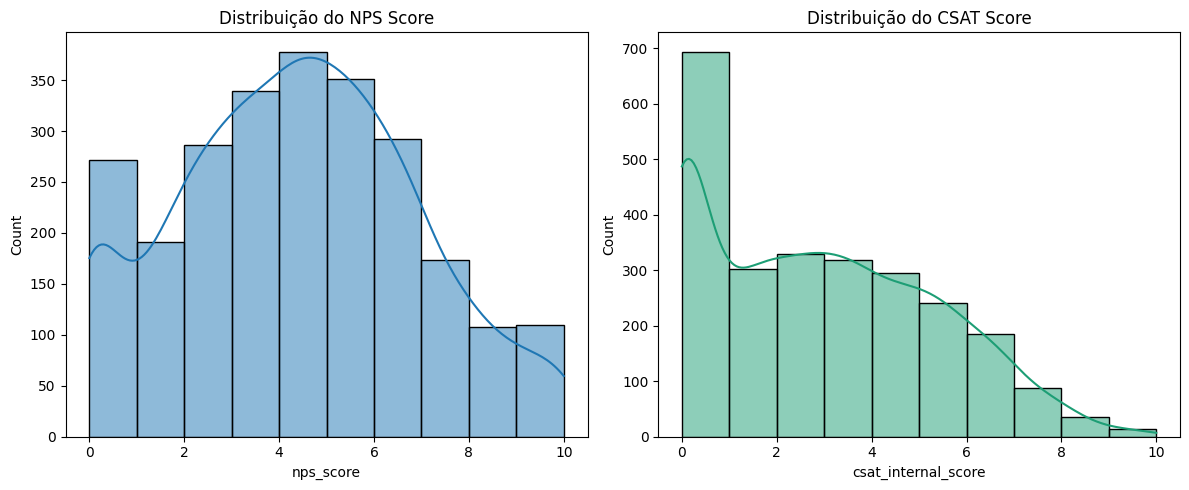

In [43]:
#distribuição percentual de cada categoria para nps e csat

distribuição_nps = nps.value_counts(normalize=True) * 100
distribuição_csat = csat.value_counts(normalize=True) * 100
print("Distribuição NPS:")
print(distribuição_nps)
print("\nDistribuição CSAT:")
print(distribuição_csat)

#grafico histrograma para nps_score e csat_score
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['nps_score'], bins=10, kde=True)
plt.title('Distribuição do NPS Score')
plt.subplot(1, 2, 2)
sns.histplot(df['csat_internal_score'], bins=10, kde=True, color="#1D9E75")
plt.title('Distribuição do CSAT Score')
plt.tight_layout()
plt.show()


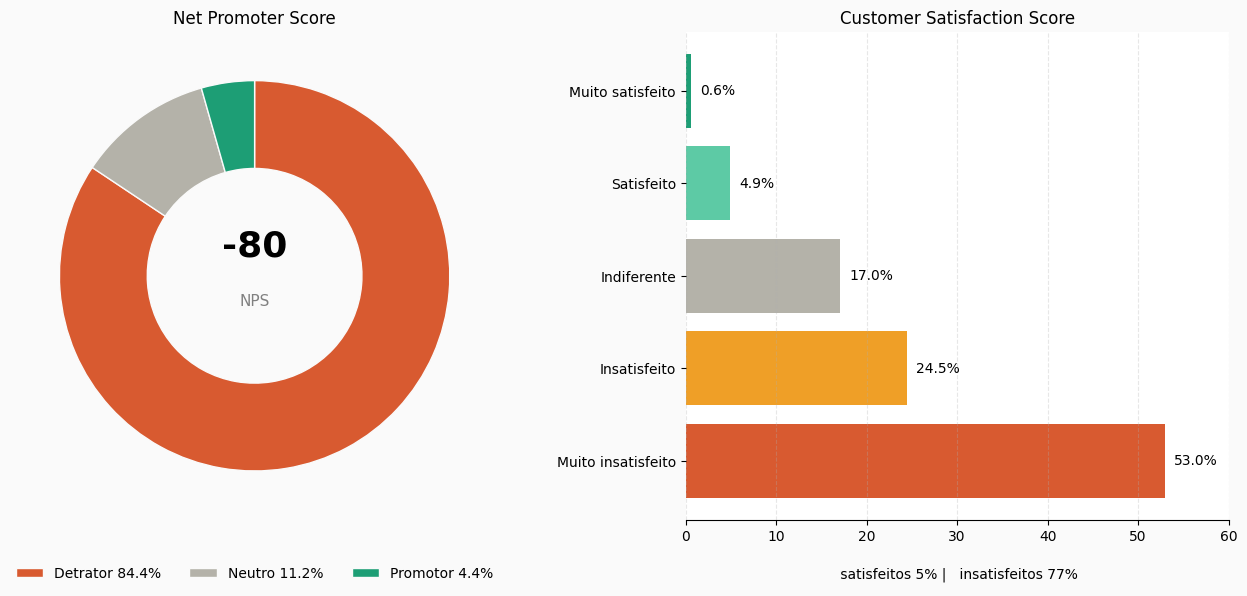

In [96]:
fig, (ax_nps, ax_csat) = plt.subplots(1, 2, figsize=(13, 6))
fig.patch.set_facecolor('#FAFAFA')

# ── NPS (rosca) ─────────────────────
COLORS_NPS = ['#D85A30', '#B4B2A9', '#1D9E75']
labels_nps = ['Detrator', 'Neutro', 'Promotor']
sizes_nps = [pct_nps.get(l, 0) for l in labels_nps]

ax_nps.pie(
    sizes_nps,
    colors=COLORS_NPS,
    startangle=90,
    wedgeprops=dict(width=0.45, edgecolor='#FAFAFA'),
    counterclock=False
)

ax_nps.text(0, 0.1, f'{nps_score:+}', ha='center', fontsize=26, fontweight='bold')
ax_nps.text(0, -0.15, 'NPS', ha='center', fontsize=11, color='gray')
ax_nps.set_title('Net Promoter Score')

ax_nps.legend(
    [f'{l} {pct_nps.get(l,0)*100:.1f}%' for l in labels_nps],
    loc='lower center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=3,
    frameon=False
)


# ── CSAT (barras) ───────────────────
COLORS_CSAT = ['#D85A30', '#EF9F27', '#B4B2A9', '#5DCAA5', '#1D9E75']
labels_csat = ['Muito insatisfeito', 'Insatisfeito', 'Indiferente', 'Satisfeito', 'Muito satisfeito']
sizes_csat = [pct_csat.get(l, 0) * 100 for l in labels_csat]

bars = ax_csat.barh(labels_csat, sizes_csat, color=COLORS_CSAT)

for bar in bars:
    w = bar.get_width()
    ax_csat.text(w + 1, bar.get_y() + bar.get_height()/2,
                 f'{w:.1f}%', va='center')

ax_csat.set_xlim(0, 60)
ax_csat.set_title('Customer Satisfaction Score')
ax_csat.spines[['top', 'right', 'left']].set_visible(False)
ax_csat.grid(axis='x', linestyle='--', alpha=0.3)

# resumo (satisfeitos vs insatisfeitos)
insat = (pct_csat.get('Muito insatisfeito', 0) +
         pct_csat.get('Insatisfeito', 0)) * 100

ax_csat.text(
    0.5, -0.12,  # centralizado horizontalmente, abaixo do gráfico
    f' satisfeitos {csat_score}% |   insatisfeitos {insat:.0f}%',
    transform=ax_csat.transAxes,
    ha='center',
)


plt.tight_layout()
plt.show()

Tá bem crítico aqui: o NPS em -80 mostra que a grande maioria é detratora, quase ninguém promovendo. E o CSAT reforça isso, mais de 75% estão insatisfeitos, com pouquíssimos satisfeitos. Claramente tem um problema sério na experiência que precisa ser investigado rápido

---

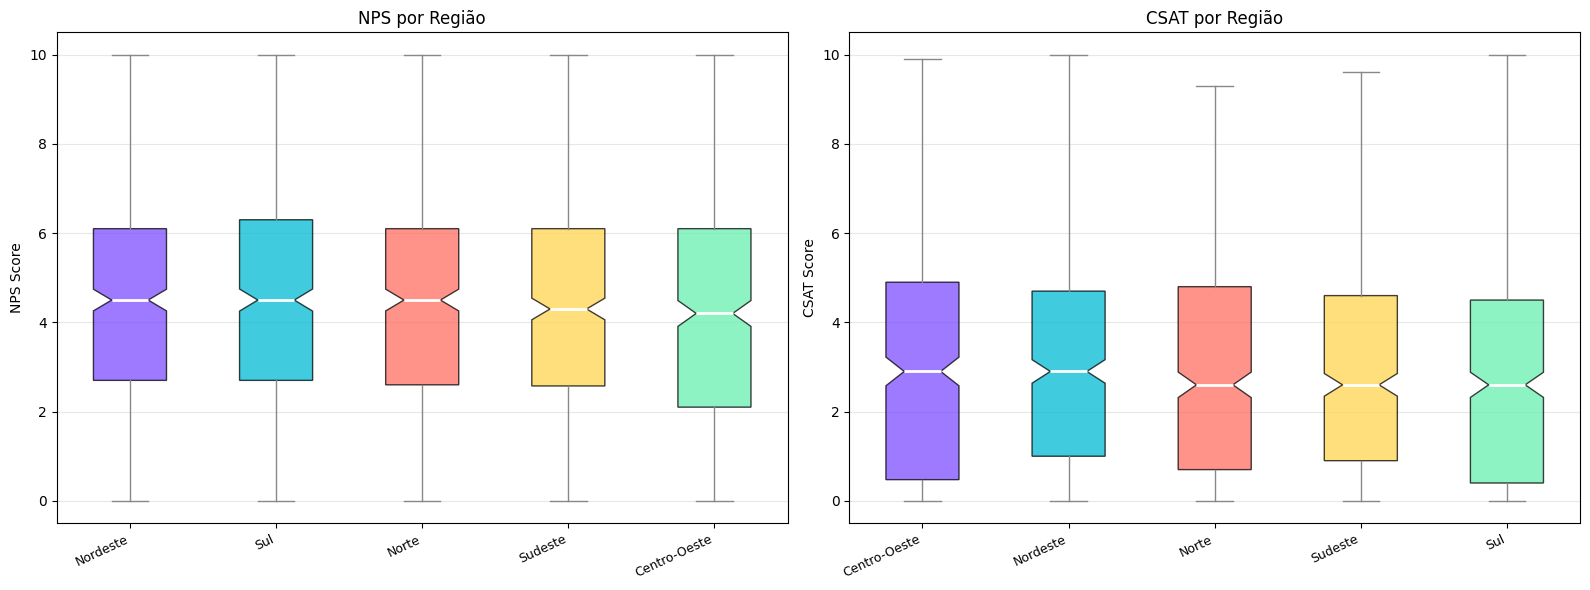

In [45]:
# Boxplots customizados de NPS e CSAT por região, lado a lado

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- NPS por Região ---
regs_nps = df.groupby('customer_region')['nps_score'].median().sort_values(ascending=False).index
data_nps = [df[df['customer_region'] == r]['nps_score'].values for r in regs_nps]

bp1 = ax1.boxplot(
    data_nps,
    patch_artist=True,
    notch=True,
    medianprops={'color': '#fff', 'linewidth': 2},
    whiskerprops={'color': '#888'},
    capprops={'color': '#888'},
    flierprops={'marker': 'o', 'markerfacecolor': '#ff6b6b', 'markersize': 3, 'alpha': 0.4}
)
for patch, color in zip(bp1['boxes'], REGION_PAL):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
ax1.set_xticklabels(regs_nps, rotation=25, ha='right', fontsize=9)
ax1.set_title('NPS por Região')
ax1.set_ylabel('NPS Score')
ax1.grid(axis='y', alpha=0.3)

# --- CSAT por Região ---
regs_csat = df.groupby('customer_region')['csat_internal_score'].median().sort_values(ascending=False).index
data_csat = [df[df['customer_region'] == r]['csat_internal_score'].values for r in regs_csat]

bp2 = ax2.boxplot(
    data_csat,
    patch_artist=True,
    notch=True,
    medianprops={'color': '#fff', 'linewidth': 2},
    whiskerprops={'color': '#888'},
    capprops={'color': '#888'},
    flierprops={'marker': 'o', 'markerfacecolor': '#ff6b6b', 'markersize': 3, 'alpha': 0.4}
)
for patch, color in zip(bp2['boxes'], REGION_PAL):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
ax2.set_xticklabels(regs_csat, rotation=25, ha='right', fontsize=9)
ax2.set_title('CSAT por Região')
ax2.set_ylabel('CSAT Score')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Aqui já dá pra ver que não tem uma diferença muito gritante entre as regiões. Os NPS ficam todos bem parecidos, ali na faixa média, com bastante variação dentro de cada uma. No CSAT é a mesma história: nenhuma região se destaca muito, todas seguem um padrão bem parecido e com dispersão alta. Parece mais um problema geral da experiência do que algo específico de uma região.

---

C:\Users\Lucas\AppData\Local\Temp\ipykernel_9056\3159104604.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Lucas\AppData\Local\Temp\ipykernel_9056\3159104604.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


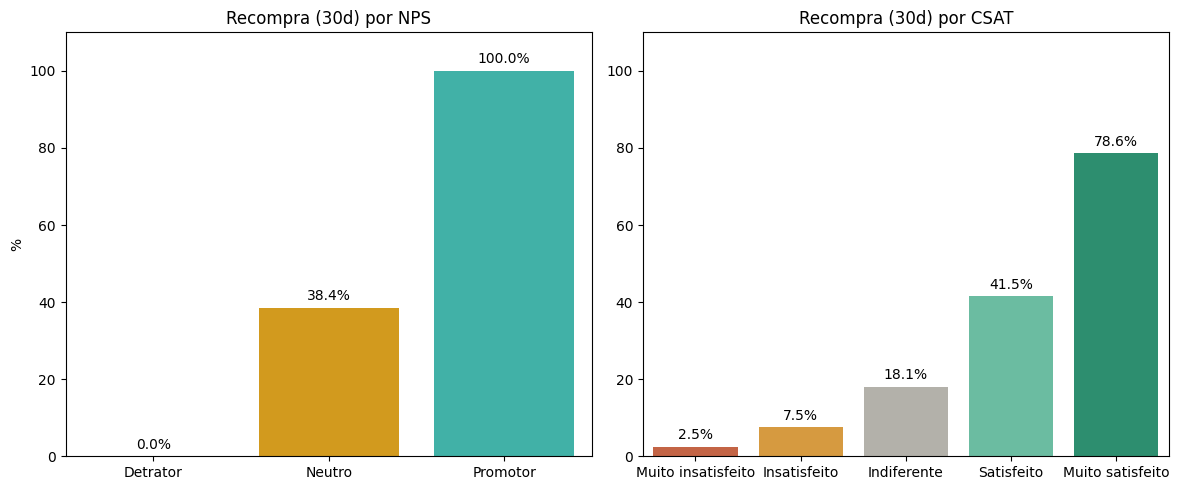

In [46]:
# ── Cálculos ────────────────────────
taxa_recompra_nps = df.groupby('nps_category')['repeat_purchase_30d'].mean() * 100
taxa_recompra_csat = df.groupby('csat_category')['repeat_purchase_30d'].mean() * 100

# ── Plot ────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# NPS
sns.barplot(
    x=taxa_recompra_nps.index,
    y=taxa_recompra_nps.values,
    palette=[NPS_COLORS.get(cat, '#888') for cat in taxa_recompra_nps.index],
    ax=ax1
)
ax1.set_title('Recompra (30d) por NPS')
ax1.set_ylabel('%')
ax1.set_xlabel('')
ax1.set_ylim(0, 110)

for i, v in enumerate(taxa_recompra_nps.values):
    ax1.text(i, v + 2, f'{v:.1f}%', ha='center')


# CSAT
sns.barplot(
    x=taxa_recompra_csat.index,
    y=taxa_recompra_csat.values,
    palette=[COLORS_CSAT[i] for i in range(len(taxa_recompra_csat))],
    ax=ax2
)
ax2.set_title('Recompra (30d) por CSAT')
ax2.set_ylabel('')
ax2.set_xlabel('')
ax2.set_ylim(0, 110)

for i, v in enumerate(taxa_recompra_csat.values):
    ax2.text(i, v + 2, f'{v:.1f}%', ha='center')


plt.tight_layout()
plt.show()

Opa! Aqui fica bem claro o padrão: quanto mais satisfeito o cliente, maior a recompra. Promotores estão com 100%, enquanto detratores praticamente não recompram. No CSAT acontece a mesma coisa, os muito satisfeitos têm uma recompra bem alta, e os insatisfeitos quase não voltam. É uma relação bem direta entre satisfação e retenção.

---
### Impacto da Entrega no NPS

C:\Users\Lucas\AppData\Local\Temp\ipykernel_9056\3518571595.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Lucas\AppData\Local\Temp\ipykernel_9056\3518571595.py:15: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  sns.barplot(


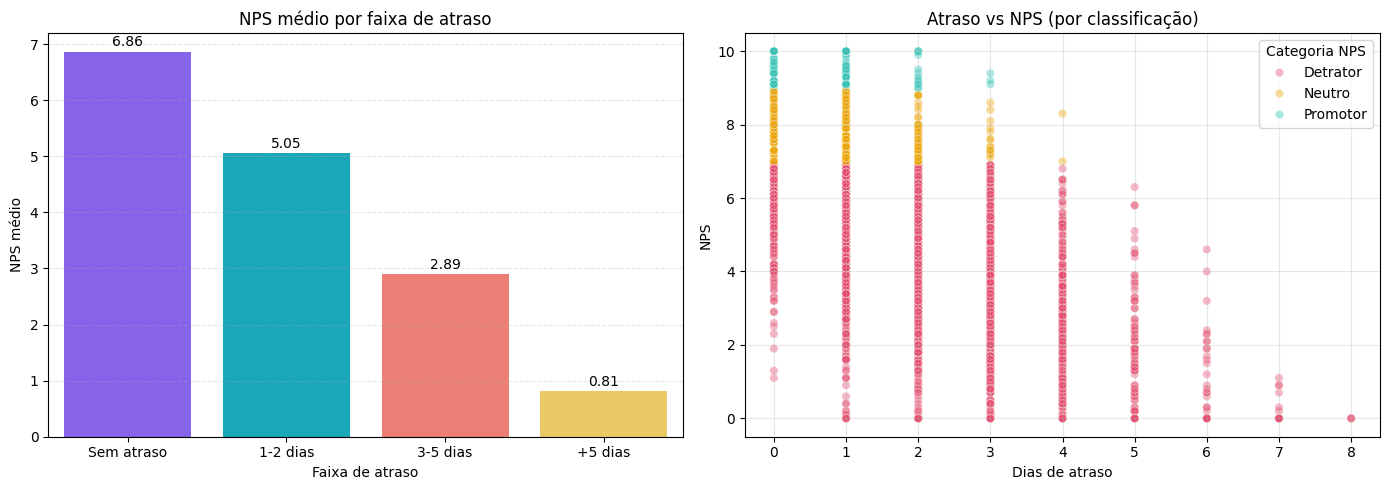

In [47]:
faixas_atraso = pd.cut(
    df['delivery_delay_days'],
    bins=[-float('inf'), 0, 2, 5, float('inf')],
    labels=['Sem atraso', '1-2 dias', '3-5 dias', '+5 dias']
)

nps_medio_atraso = df.groupby(faixas_atraso)['nps_score'].mean()

nps_medio_atraso = nps_medio_atraso * 1 

#grafico de colunas 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ── Barplot (NPS médio por faixa) ───
sns.barplot(
    x=nps_medio_atraso.index,
    y=nps_medio_atraso.values,
    palette=REGION_PAL,
    ax=ax1
)

ax1.set_title('NPS médio por faixa de atraso')
ax1.set_xlabel('Faixa de atraso')
ax1.set_ylabel('NPS médio')

for i, v in enumerate(nps_medio_atraso.values):
    ax1.text(i, v + 0.1, f'{v:.2f}', ha='center')

ax1.grid(axis='y', linestyle='--', alpha=0.3)


# ── Scatter (relação atraso vs NPS) ─
sns.scatterplot(
    x='delivery_delay_days',
    y='nps_score',
    hue='nps_category',
    data=df,
    palette=NPS_COLORS,
    alpha=0.4,
    ax=ax2
)

ax2.set_title('Atraso vs NPS (por classificação)')
ax2.set_xlabel('Dias de atraso')
ax2.set_ylabel('NPS')
ax2.grid(alpha=0.3)

ax2.legend(title='Categoria NPS')

plt.tight_layout()
plt.show()

Interessante, os gráfico confirma bem a intuição: conforme o atraso aumenta, o NPS cai rápido. Pra manter um NPS saudável, a margem pra atraso é praticamente zero.

Ao mesmo tempo, dá pra ver que existem detratores mesmo com entrega pontual, o que indica que o atraso não é o único fator, provavelmente tem outros pontos da experiência pesando bastante

---

### Atendimento ao Cliente & Reclamações

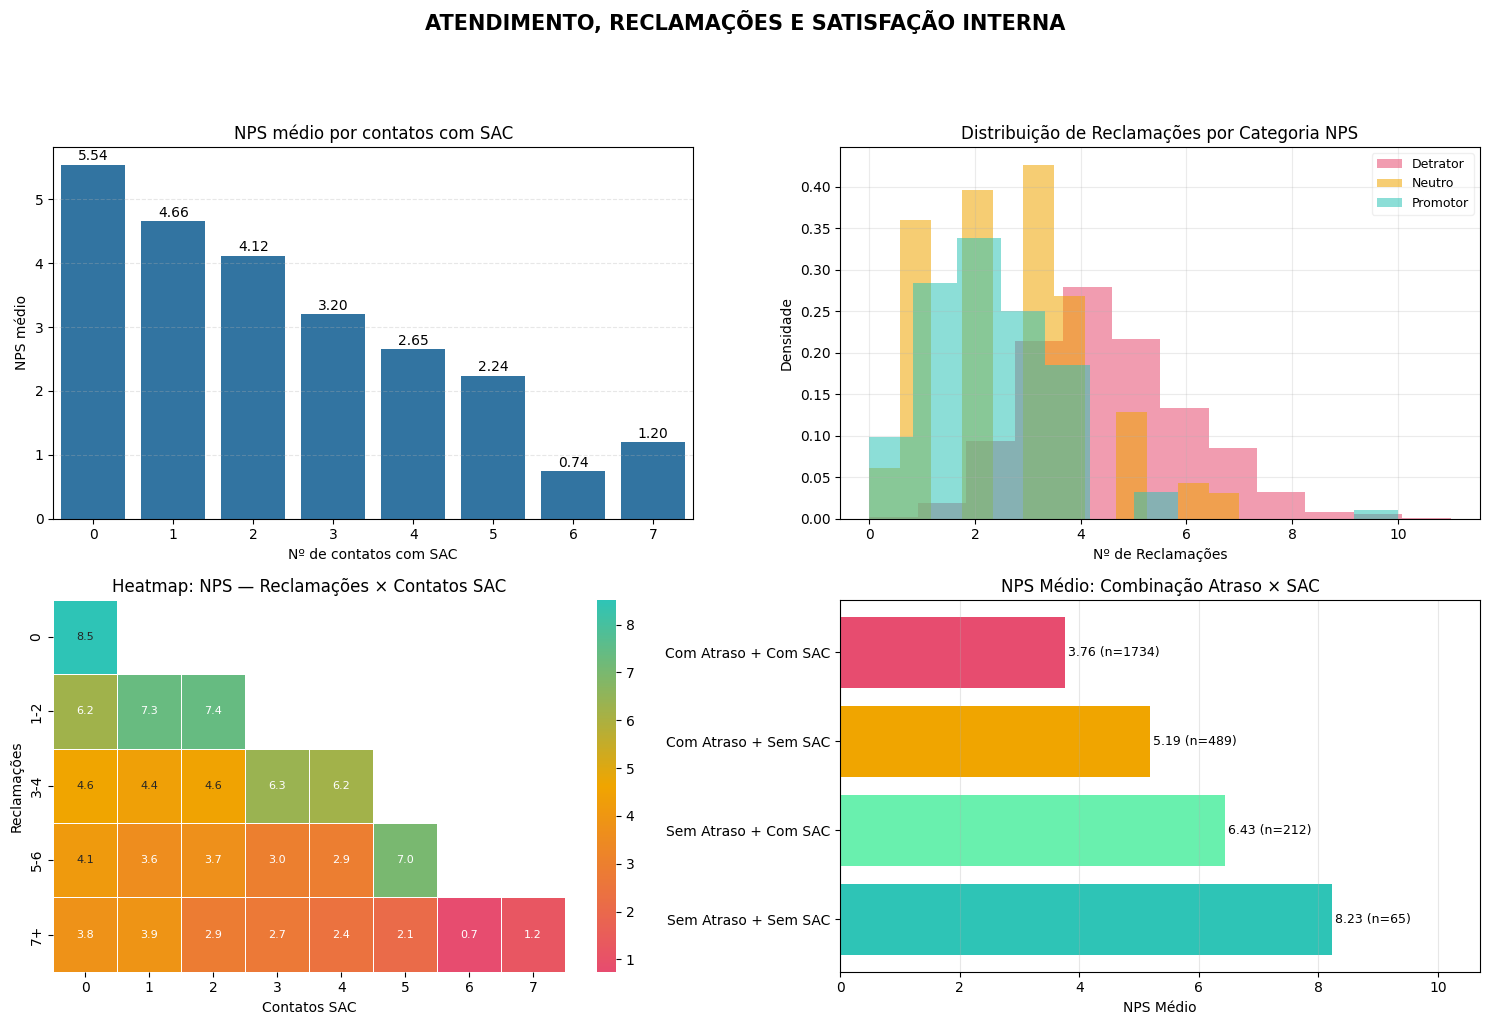

In [89]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# -------------------------
# 1) NPS médio por contatos
# -------------------------
ax1 = axes[0, 0]

sns.barplot(
    data=df,
    x='customer_service_contacts',
    y='nps_score',
    estimator='mean',
    errorbar=None,
    ax=ax1
)

ax1.set(
    title='NPS médio por contatos com SAC',
    xlabel='Nº de contatos com SAC',
    ylabel='NPS médio'
)

ax1.bar_label(ax1.containers[0], fmt='%.2f', padding=1)
ax1.grid(axis='y', linestyle='--', alpha=0.3)


# -------------------------
# 2) Histograma reclamações
# -------------------------
ax2 = axes[0, 1]

for cat, color in NPS_COLORS.items():
    ax2.hist(
        df.loc[df['nps_category'] == cat, 'complaints_count'],
        bins=12,
        alpha=0.55,
        label=cat,
        color=color,
        density=True,
        edgecolor='none'
    )

ax2.set(
    title='Distribuição de Reclamações por Categoria NPS',
    xlabel='Nº de Reclamações',
    ylabel='Densidade'
)

ax2.legend(fontsize=9, framealpha=0.3)
ax2.grid(alpha=0.25)


# -------------------------
# 3) Heatmap
# -------------------------
ax3 = axes[1, 0]

df['comp_bin'] = pd.cut(
    df['complaints_count'],
    bins=[-1, 0, 2, 4, 6, float('inf')],
    labels=['0', '1-2', '3-4', '5-6', '7+']
)

pivot2 = df.pivot_table(
    values='nps_score',
    index='comp_bin',
    columns='customer_service_contacts',
    aggfunc='mean',
    observed=True
)

sns.heatmap(
    pivot2,
    ax=ax3,
    annot=True,
    fmt='.1f',
    linewidths=0.5,
    cmap=HEAT_CMAP,
    annot_kws={'size': 8}
)

ax3.set(
    title='Heatmap: NPS — Reclamações × Contatos SAC',
    xlabel='Contatos SAC',
    ylabel='Reclamações'
)


# -------------------------
# 4) Impacto combinado atraso + SAC
# -------------------------

delay = df['delivery_delay_days'] > 0
sac = df['customer_service_contacts'] > 0

df['combo'] = (
    delay.map({False: 'Sem Atraso', True: 'Com Atraso'}) +
    ' + ' +
    sac.map({False: 'Sem SAC', True: 'Com SAC'})
)

combo_nps = (
    df.groupby('combo')
      .agg(mean=('nps_score', 'mean'), count=('nps_score', 'size'))
      .sort_values('mean', ascending=False)
)

ax4 = axes[1, 1]

bars = ax4.barh(
    combo_nps.index,
    combo_nps['mean'],
    color=['#2ec4b6','#69f0ae','#f0a500','#e74c6f']
)

for bar, row in zip(bars, combo_nps.itertuples()):
    ax4.text(
        row.mean + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"{row.mean:.2f} (n={row.count})",
        va='center',
        fontsize=9
    )

ax4.set_title('NPS Médio: Combinação Atraso × SAC')
ax4.set_xlabel('NPS Médio')
ax4.set_xlim(0, combo_nps['mean'].max() * 1.3)
ax4.grid(axis='x', alpha=0.3)

fig.suptitle(
    'ATENDIMENTO, RECLAMAÇÕES E SATISFAÇÃO INTERNA',
    fontsize=15,
    fontweight='bold',
    y=1.02
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

Aqui escancara que cada vez que o cliente precisa te procurar para reclamar de um atraso, a chance de ele se tornar um detrator aumenta drasticamente, provando que o suporte não recupera a nota que uma logística ruim já destruiu.

---

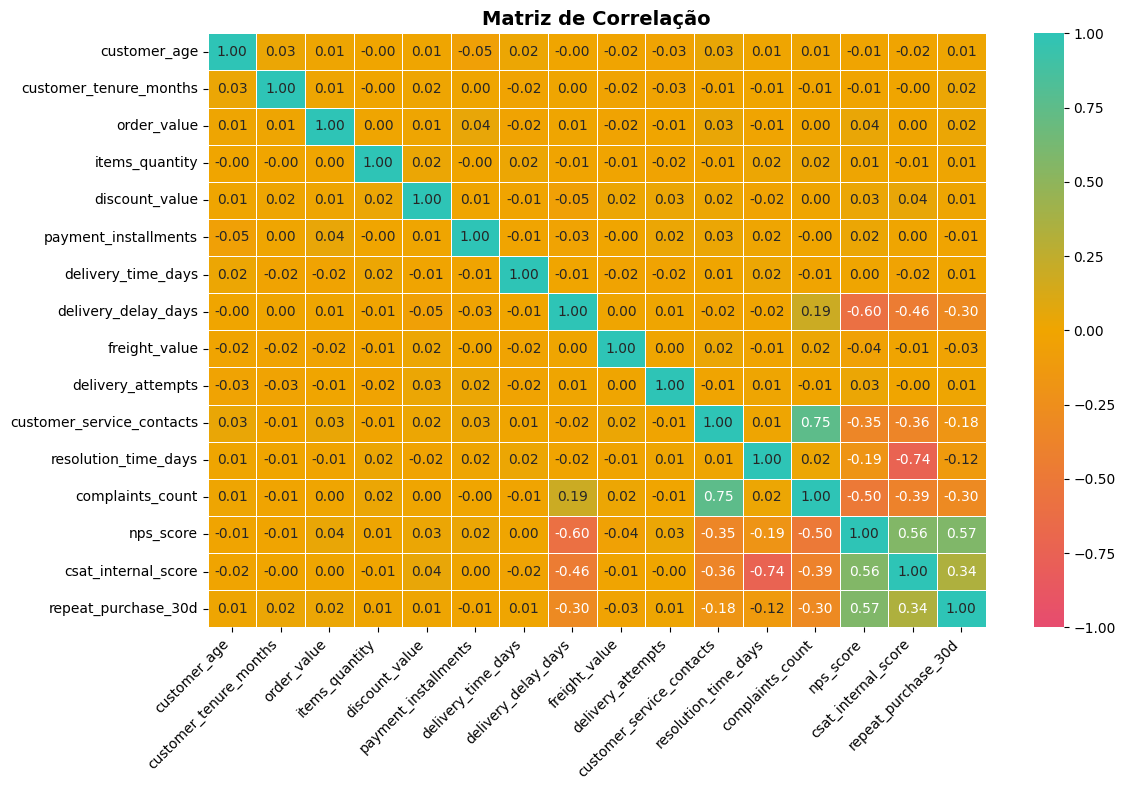

In [78]:

cols_corr = [
    'customer_age', 'customer_tenure_months', 'order_value', 'items_quantity',
    'discount_value', 'payment_installments', 'delivery_time_days',
    'delivery_delay_days', 'freight_value', 'delivery_attempts',
    'customer_service_contacts', 'resolution_time_days',
    'complaints_count', 'nps_score', 'csat_internal_score','repeat_purchase_30d'
]

cols_corr = [c for c in cols_corr if c in df.columns]
corr = df[cols_corr].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap=HEAT_CMAP,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
)

plt.title('Matriz de Correlação', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

Essa matriz nos mostra que o cliente não liga para quem ele é, mas para o quão eficiente você é: a idade ou o valor do pedido não influenciam em nada a nota, enquanto o atraso (-0.60) e o tempo de resolução (-0.74) são os verdadeiros vilões que destroem o NPS e o CSAT. O gráfico mostra um ciclo vicioso óbvio onde o atraso gera o contato, o contato vira reclamação (0.75 de correlação) e tudo isso junto soterra a satisfação

---


C:\Users\Lucas\AppData\Local\Temp\ipykernel_9056\3236115578.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


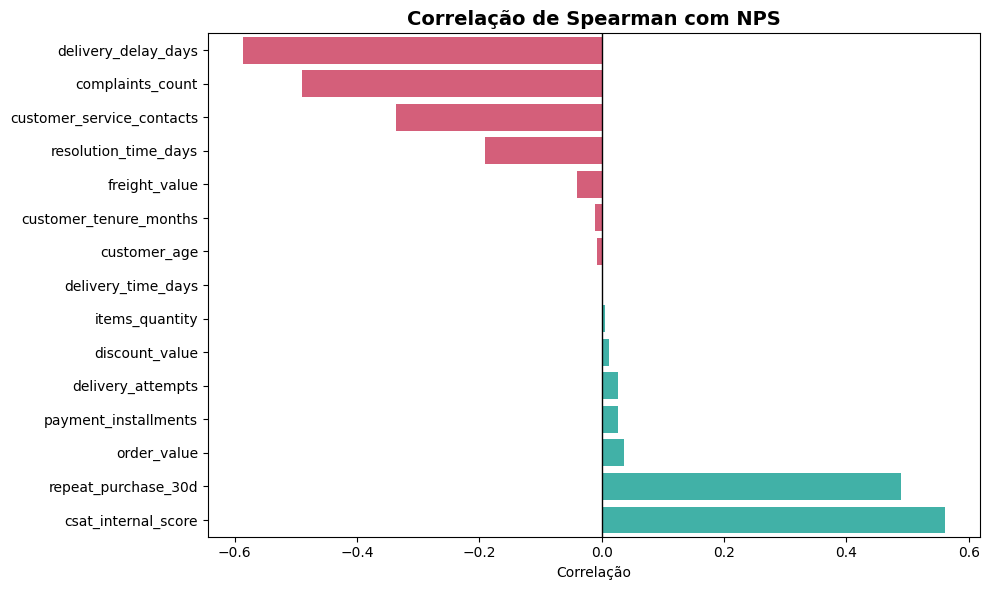

In [ ]:
corr_nps = (
    df[cols_corr]
    .corr(method='spearman')['nps_score']
    .drop('nps_score')
    .sort_values()
)
neg_color = HEAT_CMAP(0.0)  
pos_color = HEAT_CMAP(1.0)  

colors = [pos_color if v > 0 else neg_color for v in corr_nps.values]

plt.figure(figsize=(10, 6))

sns.barplot(
    y=corr_nps.index,
    x=corr_nps.values,
    palette=colors
)

plt.axvline(0, color='black', linewidth=1)

plt.title('Correlação de Spearman com NPS', fontsize=14, fontweight='bold')
plt.xlabel('Correlação')
plt.ylabel('')

plt.tight_layout()
plt.show()


Esse gráfico é o "quem é quem" daquele que destrói e daquele que anda de mão dadas ao NPS

---